# Week 7: Transfer Learning — BERT & Sentence-BERT

This notebook extends the Transformer architecture from Week 6 into full encoder stacks, then introduces BERT pre-training, fine-tuning, and Sentence-BERT (SBERT) for semantic similarity and retrieval.

## Learning Goals
- Stack multiple `TransformerBlock` layers from `utils.py` to build a complete encoder architecture.
- Understand BERT's bidirectional pre-training objectives: Masked Language Modeling (MLM) and Next Sentence Prediction (NSP).
- Fine-tune a pre-trained BERT model for IMDb sentiment classification using the Hugging Face `Trainer` API.
- Understand why BERT is slow for semantic similarity tasks and how SBERT solves this with a Siamese network.
- Build a semantic similarity pipeline with SBERT embeddings and compare against the Week 3 DAN baseline.

## Reused Assets from Week 6
This week reuses the saved IMDb tokenized assets and the `utils.py` building blocks from previous weeks.

- `../week6-transformer-attention/data/imdb_bpe_dataset.pt` (or the Week 5 path)
- `../week5-CNN-for-text/data/bpe_vocab.json`
- `../week5-CNN-for-text/data/bpe_merges.json`
- `../week5-CNN-for-text/models/vocab_config.json`
- `../week6-transformer-attention/models/tiny_transformer_imdb_rope.pt` (Week 6 checkpoint)

For Day 4 and Day 5, Hugging Face datasets and the `sentence-transformers` library are also required.

## Suggested Multi-Day Flow
- **Day 1:** Stack `TransformerBlock` layers from `utils.py` into a full encoder and probe its representations.
- **Day 2:** Explore BERT's architecture and pre-training objectives (MLM and NSP) without writing them from scratch.
- **Day 3:** Fine-tune a pre-trained BERT model on IMDb using the Hugging Face `Trainer` API.
- **Day 4:** Introduce SBERT and Siamese networks; understand why they are faster for similarity tasks.
- **Day 5:** Build a semantic search pipeline with SBERT embeddings and compare it with the Week 3 DAN baseline.

You can treat each day as one notebook checkpoint instead of trying to finish the full notebook in one sitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

# Reused directly from utils.py — same as Week 6
from utils import (
    create_bert,
    linear_cka,
    TransformerBlock,
    MultiHeadAttention,
    FeedForward,
    bpe_batch_encode,
    evaluate_binary_classifier,
    get_device,
    load_json,
    load_torch_dataset,
    masked_mean_pool,
    plot_attention_heads,
    plot_attention_heatmap,
    plot_training_history,
    train_binary_classifier,
)

In [2]:
# Asset paths — adjust to match your local folder layout
paths = {
    "dataset": Path("../week5-CNN-for-text/data/imdb_bpe_dataset.pt"),
    "bpe_vocab": Path("../week5-CNN-for-text/data/bpe_vocab.json"),
    "bpe_merges": Path("../week5-CNN-for-text/data/bpe_merges.json"),
    "vocab_config": Path("../week5-CNN-for-text/models/vocab_config.json"),
    "dan_state": Path("../week5-CNN-for-text/models/dan_imdb.pt"),
    "week6_rope_model": Path("../week6-transformer/models/tiny_transformer_imdb_rope.pt"),
}

missing = [str(p) for p in paths.values() if not p.exists()]
if missing:
    print("Warning: missing Week 6/5 assets — some cells will need the paths updated:")
    for m in missing:
        print(" ", m)
else:
    print("All asset paths found.")

input_ids, labels, attention_masks = load_torch_dataset(str(paths["dataset"]))
bpe_vocab = load_json(str(paths["bpe_vocab"]))
bpe_merges = [tuple(pair) for pair in load_json(str(paths["bpe_merges"]))]
vocab_config = load_json(str(paths["vocab_config"]))
id_to_token = {idx: token for token, idx in bpe_vocab.items()}
device = get_device()

dan_state = torch.load(paths["dan_state"], map_location=device, weights_only=True)
embedding_weight = dan_state["embedding.weight"].to(device)

print("device:", device)
print("input_ids shape:", tuple(input_ids.shape))
print("labels shape:", tuple(labels.shape))
print("attention_masks shape:", tuple(attention_masks.shape))
print("vocab size:", vocab_config["vocab_size"])
print("pad id:", vocab_config["pad_id"])
print("embedding_weight shape:", tuple(embedding_weight.shape))

All asset paths found.
device: mps
input_ids shape: (50000, 128)
labels shape: (50000,)
attention_masks shape: (50000, 128)
vocab size: 590
pad id: 589
embedding_weight shape: (590, 384)


## Day 1: Building a Full Transformer Encoder

The goal for Day 1 is to stack the `TransformerBlock` layers from `utils.py` into a full encoder and understand how layer depth changes the representations it builds.

### From Block to Encoder

In Week 6 we built and inspected a single `TransformerBlock`. An encoder is simply a stack of those blocks, one after another. Each block receives the output of the previous one as its new `x`, so representations accumulate context across layers.

The full encoder pipeline (if using absolute position encoding) is:

$$
x_0 = \text{Embedding}(\text{input\_ids}) + \text{PositionalEncoding}
$$
$$
x_l = \text{TransformerBlock}_l(x_{l-1}), \quad l = 1, \ldots, L
$$
$$
h = \text{LayerNorm}(x_L)
$$

The `TinyBERT` class from `utils.py` already does exactly this except it uses rotary position encoding — it is a stacked encoder. Today we look *inside* it: we probe the representation at each layer using CKA (Centered Kernel Alignment) to see how much layers agree with each other.

### Layer Similarity with CKA

A simple way to compare representations at two layers is **linear Centered Kernel Alignment (CKA)**. For two representation matrices $X$ and $Y$ (each of shape `[n_examples, d]`), linear CKA is:

$$
\text{CKA}(X, Y) = \frac{\lVert Y^T X \rVert_F^2}{\lVert X^T X \rVert_F \cdot \lVert Y^T Y \rVert_F}
$$

CKA ranges from 0 (representations are completely different) to 1 (representations are identical up to linear transformation). It is a useful diagnostic for checking whether later encoder layers are actually building on top of earlier ones or just repeating themselves.

A few things to expect:
- Adjacent layers tend to be more similar (higher CKA) than distant ones.
- The very first and last layers often differ the most — early layers encode surface features while later layers encode more abstract patterns.
- Because our encoder here is untrained (we reuse frozen BPE embeddings and random block weights), the CKA pattern will look noisier than in a trained model.

The Frobenius norm is defined as the square root of the sum of the absolute squares of its elements:

$$ |A|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2} $$

It can also be written elegantly in terms of the matrix trace:

$$ |A|_F = \sqrt{\text{Tr}(A^T A)} $$

In [3]:
# Initialize our TinyBERT encoder from scratch
num_layers = 4
num_heads = 4
vocab_size = vocab_config["vocab_size"]
d_model = embedding_weight.size(1)  
pad_id = vocab_config["pad_id"]

tiny_bert = create_bert(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    mlp_hidden_dim=4 * d_model,
    num_layers=num_layers,
    pad_id=pad_id,
    use_rope=True,
    use_absolute_positions=False,
    pretrained_embedding_weight=embedding_weight.detach().cpu()
).to(device)


print(f"TinyBERT Parameters: {sum(p.numel() for p in tiny_bert.parameters())}")
print(tiny_bert)

TinyBERT Parameters: 7325184
TinyBERT(
  (embedding): Embedding(590, 384, padding_idx=589)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (self_attn_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (self_attn): MultiHeadAttention(
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (k_proj): Linear(in_features=384, out_features=384, bias=True)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (ffn_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0.1, inplace=False)
     

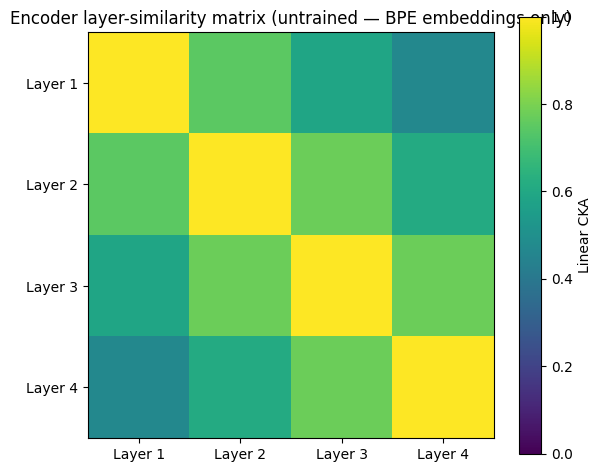

CKA matrix (row i, col j = similarity between layer i and layer j):
tensor([[1.0000, 0.7460, 0.5880, 0.4670],
        [0.7460, 1.0000, 0.7760, 0.6100],
        [0.5880, 0.7760, 1.0000, 0.7740],
        [0.4670, 0.6100, 0.7740, 1.0000]])


In [4]:
tiny_bert.eval()

probe_size = 128
probe_ids = input_ids[:probe_size, :].to(device)
probe_masks = attention_masks[:probe_size, :].to(device)

# Collect layer representations manually
layer_reps = []
with torch.no_grad():
    x = tiny_bert.embedding(probe_ids)
    x = tiny_bert.dropout(x)
    for block in tiny_bert.blocks:
        x = block(x=x, attention_mask=probe_masks)
        pooled = masked_mean_pool(x, probe_masks)  # [n, d]
        layer_reps.append(pooled.detach().cpu())

# Compute pairwise CKA
n_layers = len(layer_reps)
cka_matrix = torch.zeros(n_layers, n_layers)
for i in range(n_layers):
    for j in range(n_layers):
        cka_matrix[i, j] = linear_cka(layer_reps[i], layer_reps[j])

plt.figure(figsize=(6, 5))
plt.imshow(cka_matrix.numpy(), vmin=0, vmax=1, cmap="viridis")
plt.colorbar(label="Linear CKA")
plt.xticks(range(n_layers), [f"Layer {i+1}" for i in range(n_layers)])
plt.yticks(range(n_layers), [f"Layer {i+1}" for i in range(n_layers)])
plt.title("Encoder layer-similarity matrix (untrained — BPE embeddings only)")
plt.tight_layout()
plt.show()

print("CKA matrix (row i, col j = similarity between layer i and layer j):")
print(cka_matrix.round(decimals=3))

### What the CKA Matrix Tells Us

Even in an untrained encoder the diagonal is always 1 (a layer is perfectly similar to itself). Off-diagonal values show whether layers are building genuinely different representations or largely redundant ones. In a well-trained deep encoder you typically see a staircase pattern where nearby layers are very similar and distant layers diverge, which indicates the encoder is progressively refining its representations rather than repeating the same computation.

## Day 2: BERT Architecture and Pre-Training

The goal for Day 2 is to understand BERT's architecture and the two pre-training objectives that give it strong general-purpose representations, before we fine-tune it on a specific task.

### What BERT Is

BERT (Bidirectional Encoder Representations from Transformers) is a stacked Transformer encoder pre-trained on a large corpus with two self-supervised objectives. Its main architectural properties:

- **Bidirectional self-attention:** unlike a decoder, every token can attend to every other token in both directions. This is the same attention mechanism in `utils.py`'s `MultiHeadAttention` with `is_causal=False`.
- **Special tokens:** `[CLS]` at the start of every sequence accumulates a sequence-level representation; `[SEP]` separates two segments in a paired input.
- **Token type embeddings:** an extra learned embedding (0 or 1) marks which segment each token belongs to — used for NSP.
- **Absolute positional embeddings:** BERT uses *learned* (not sinusoidal) absolute position embeddings added once after the token embedding. This is the same design as the `use_absolute_positions=True` path in `TinyTransformerClassifier`, except BERT learns its position table rather than using the fixed sinusoidal formula.

BERT-base has 12 layers, 12 heads, `d_model=768`, and roughly 110M parameters. BERT-large has 24 layers, 16 heads, `d_model=1024`, and ~340M parameters.

### Masked Language Modeling (MLM)

MLM is BERT's main pre-training objective. During pre-training, 15% of input tokens are selected at random. Of those:
- 80% are replaced with a `[MASK]` token.
- 10% are replaced with a random vocabulary token.
- 10% are left unchanged.

The model must predict the original token at every masked position using the surrounding (both left and right) context:

$$
\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P(x_i \mid \tilde{x})
$$

where $\mathcal{M}$ is the set of masked positions and $\tilde{x}$ is the corrupted sequence. This forces every encoder layer to build rich bidirectional contextual representations because no causal mask restricts which tokens can see which others.

This is very different from the GPT-style causal language model objective where each token can only attend to past tokens. MLM gives BERT access to full context at the cost of not being autoregressive — so BERT is an encoder, not a generator.

### Next Sentence Prediction (NSP)

NSP is BERT's secondary pre-training objective. The model receives a pair of segments separated by `[SEP]` and must predict whether the second segment actually followed the first in the original corpus (positive pair) or is a random segment (negative pair):

$$
\mathcal{L}_{\text{NSP}} = -\log P(\text{IsNext} \mid h_{[\text{CLS}]})
$$

The classification is made from the `[CLS]` token's hidden state. NSP was designed to teach cross-sentence reasoning, though later work (RoBERTa, ALBERT) found that removing NSP often helps rather than hurts downstream task performance. The intuition is that MLM already provides a strong enough signal; NSP can add noise because the randomly sampled negative pairs are trivially easy to identify from topic mismatch alone.

Despite that criticism, understanding NSP is important because it explains two BERT design choices that you will see throughout the Hugging Face API: the `[CLS]` token at position 0 and the `token_type_ids` input.

### BERT Pre-training Is Not Run Here

Pre-training BERT requires hundreds of gigabytes of text and thousands of GPU hours. We do not reproduce it. Instead, we use Hugging Face's `transformers` library to load a checkpoint that has already been pre-trained, then inspect its structure below.

The important takeaway from Day 2 is the *shape* of the pre-training objectives:
- MLM teaches the model to predict masked tokens from bidirectional context → general token-level representations.
- NSP teaches the model whether two segments are adjacent → a sequence-level representation in `[CLS]`.

Fine-tuning (Day 3) replaces the pre-training heads with a task head and continues training on labeled data.

In [5]:
# Day 2: Inspect a pre-trained BERT checkpoint
# This cell loads the model architecture and prints the layer names so we can see the
# correspondence between BERT's components and what we built in Week 6.

from transformers import BertTokenizer, BertModel, BertForMaskedLM

bert_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(bert_name)
bert_model = BertModel.from_pretrained(bert_name)

print("=== BERT-base architecture summary ===")
total_params = sum(p.numel() for p in bert_model.parameters())
print(f"Total parameters: {total_params:,} ({total_params / 1e6:.1f}M)")
print(f"Number of encoder layers: {bert_model.config.num_hidden_layers}")
print(f"Number of attention heads: {bert_model.config.num_attention_heads}")
print(f"Hidden size (d_model): {bert_model.config.hidden_size}")
print(f"Intermediate FFN size: {bert_model.config.intermediate_size}")
print(f"Vocab size: {bert_model.config.vocab_size}")
print(f"Max position embeddings: {bert_model.config.max_position_embeddings}")
print()
print("TinyBert for comparison:")
print(f"  d_model: {d_model}, num_layers: 4, num_heads: 4")
tiny_params = sum(p.numel() for p in tiny_bert.parameters())
print(f"  Total parameters: {tiny_params:,} ({tiny_params / 1e6:.2f}M)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== BERT-base architecture summary ===
Total parameters: 109,482,240 (109.5M)
Number of encoder layers: 12
Number of attention heads: 12
Hidden size (d_model): 768
Intermediate FFN size: 3072
Vocab size: 30522
Max position embeddings: 512

TinyBert for comparison:
  d_model: 384, num_layers: 4, num_heads: 4
  Total parameters: 7,325,184 (7.33M)


In [6]:
# Day 2: Visualize MLM by masking tokens and asking BERT to fill them in
# This is the closest we can get to watching the pre-training objective in action
# without actually training.

from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased", device=device)

probe_sentences = [
    "The film was absolutely [MASK], I could not stop watching.",
    "The acting was [MASK] but the plot was predictable and dull.",
    "I would [MASK] this movie to anyone who enjoys slow-burn thrillers.",
]

print("=== BERT MLM predictions (top-3 per mask) ===")
for sentence in probe_sentences:
    results = fill_mask(sentence)
    print(f"\nSentence: {sentence}")
    for result in results[:3]:
        print(f"  [{result['score']:.3f}] {result['token_str']:15s} → {result['sequence']}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== BERT MLM predictions (top-3 per mask) ===

Sentence: The film was absolutely [MASK], I could not stop watching.
  [0.191] beautiful       → the film was absolutely beautiful, i could not stop watching.
  [0.110] incredible      → the film was absolutely incredible, i could not stop watching.
  [0.095] stunning        → the film was absolutely stunning, i could not stop watching.

Sentence: The acting was [MASK] but the plot was predictable and dull.
  [0.594] good            → the acting was good but the plot was predictable and dull.
  [0.096] excellent       → the acting was excellent but the plot was predictable and dull.
  [0.063] fine            → the acting was fine but the plot was predictable and dull.

Sentence: I would [MASK] this movie to anyone who enjoys slow-burn thrillers.
  [0.926] recommend       → i would recommend this movie to anyone who enjoys slow - burn thrillers.
  [0.011] give            → i would give this movie to anyone who enjoys slow - burn thrillers.


In [8]:
# Day 2: Compare token representations from early vs late BERT layers
# This is the BERT-scale version of the CKA probe we ran in Day 1.

from transformers import BertModel

bert_probe = BertModel.from_pretrained(bert_name, output_hidden_states=True).to(device)
bert_probe.eval()

probe_texts = [
    "The cinematography was breathtaking and the performances were superb.",
    "A tedious and poorly written film that wasted two hours of my life.",
    "Somewhere between brilliant and baffling, this film defies easy categorisation.",
]

encoded = tokenizer(probe_texts, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = bert_probe(**encoded)

# hidden_states: tuple of (num_layers + 1) tensors, each [batch, seq, 768]
# Index 0 is the embedding layer output; indices 1..12 are the 12 encoder layers.
hidden_states = outputs.hidden_states
print(f"Number of hidden state tensors (embedding + {bert_probe.config.num_hidden_layers} layers):",
      len(hidden_states))
print(f"Shape of each hidden state tensor: {tuple(hidden_states[0].shape)}")

# Compare [CLS] representations across layers using cosine similarity
cls_vectors = torch.stack([h[:, 0, :] for h in hidden_states], dim=0)  # [13, 3, 768]
print("\n[CLS] cosine similarity between layer 1 and layer 12 per example:")
for i, text in enumerate(probe_texts):
    v_early = cls_vectors[1, i]
    v_late = cls_vectors[12, i]
    cosine_sim = torch.nn.functional.cosine_similarity(v_early.unsqueeze(0), v_late.unsqueeze(0)).item()
    print(f"For text {text[:60]}...")
    print(f" cosine similarity [{cosine_sim:.3f}]")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of hidden state tensors (embedding + 12 layers): 13
Shape of each hidden state tensor: (3, 20, 768)

[CLS] cosine similarity between layer 1 and layer 12 per example:
For text The cinematography was breathtaking and the performances wer...
 cosine similarity [0.204]
For text A tedious and poorly written film that wasted two hours of m...
 cosine similarity [0.163]
For text Somewhere between brilliant and baffling, this film defies e...
 cosine similarity [0.199]


### Key Takeaways from Day 2

The architecture inside `BertModel` maps directly onto what we built in Week 6:
- `BertEmbeddings` = token embedding + positional embedding + token type embedding.
- Each `BertLayer` = a `TransformerBlock` from `utils.py` with `is_causal=False` and no RoPE (BERT uses learned absolute positions).
- The `[CLS]` hidden state at layer 12 is what BERT fine-tuning uses for classification — this is the sequence-level representation that NSP was designed to enrich.

A low cosine similarity between early and late `[CLS]` vectors tells us the encoder is doing real work: the representation at layer 12 looks quite different from the raw embedding output.

## Day 3: Fine-tuning BERT

**Goal:** Hands-on with fine-tuning a pre-trained BERT model for a classification task using the Hugging Face `Trainer` API.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

# 1. Load the IMDB dataset (our anchor dataset)
# dataset = load_dataset("imdb")

# 2. Load pre-trained BERT tokenizer and model for sequence classification
model_name = "prajjwal1/bert-tiny" # Using a tiny BERT for speed
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 3. Example tokenization
sample_text = "This movie was absolutely fantastic!"
tokens = tokenizer(sample_text, return_tensors="pt")
print("Tokens:", tokens)

# 4. Forward pass
outputs = model(**tokens)
print("Logits:", outputs.logits)

## Day 4: Sentence-BERT (SBERT) and Siamese Networks

**Goal:** Introduce SBERT and Siamese networks. Understand why standard BERT is slow for semantic similarity and how SBERT solves this by producing sentence embeddings.

In [ ]:
from utils import create_sbert

# We can wrap our previously created TinyBERT in our SBERT wrapper
# This will apply Mean Pooling to the BERT outputs and L2 normalize them.
tiny_sbert = create_sbert(tiny_bert)

dummy_attention_mask = torch.ones_like(dummy_inputs)
sentence_embeddings = tiny_sbert(dummy_inputs, dummy_attention_mask)

print(f"Sentence embeddings shape: {sentence_embeddings.shape} (batch_size, d_model)")
print(f"Vector norm (should be 1.0 due to L2 normalization): {torch.norm(sentence_embeddings[0]).item():.4f}")

## Day 5: SBERT in Action (Semantic Search)

**Goal:** Implement semantic search or retrieval using SBERT embeddings and compare performance with Week 3's baseline.

In [ ]:
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer

# Load a pre-trained SBERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove a fast car."
]

# Generate embeddings
embeddings = sbert_model.encode(sentences, convert_to_tensor=True)

# Compute Cosine Similarities
sim_0_1 = F.cosine_similarity(embeddings[0].unsqueeze(0), embeddings[1].unsqueeze(0))
sim_0_2 = F.cosine_similarity(embeddings[0].unsqueeze(0), embeddings[2].unsqueeze(0))

print(f"Similarity ('{sentences[0]}' vs '{sentences[1]}'): {sim_0_1.item():.4f}")
print(f"Similarity ('{sentences[0]}' vs '{sentences[2]}'): {sim_0_2.item():.4f}")